# Análise Exploratória — Emissões de GEE da Agropecuária Brasileira (SEEG)
## Foco: Cultura da Soja (2019–2024)

Este notebook realiza uma análise exploratória de dados (EDA) completa sobre as bases de emissões de gases de efeito estufa (GEE) do **SEEG (Sistema de Estimativas de Emissões e Remoções de Gases de Efeito Estufa)**, das regiões Centro-Oeste e Sul com foco na cultura da **soja** no período de **2019 a 2024**, incluindo comparações com outras culturas e análise de correlação.

### Bases utilizadas
| Arquivo | Conteúdo |
|---|---|
| `ar2_processed.csv` | Emissões em CO2e, convertidas pelos fatores de GWP/GTP do **2º Relatório do IPCC (AR2)** |
| `ar4_processed.csv` | Emissões em CO2e, fatores do **4º Relatório do IPCC (AR4)** |
| `ar5_processed.csv` | Emissões em CO2e, fatores do **5º Relatório do IPCC (AR5)** |
| `ar6_processed.csv` | Emissões em CO2e, fatores do **6º Relatório do IPCC (AR6)** — metodologia mais atual |
| `gases_processed.csv` | Emissões desagregadas por gás (CH4, N2O, CO2), sem conversão para CO2e |

Cada linha representa uma combinação de setor, categoria/subcategoria emissora, produto/sistema, bioma, tipo de emissão (direta/indireta), gás e localização (município/estado), com colunas de valores anuais de **1970 a 2024**.

> **Como executar**: coloque os 5 arquivos `*_processed.csv` originais na mesma pasta deste notebook (ou ajuste `DATA_DIR` abaixo).


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

DATA_DIR = '.'  # ajuste se os arquivos estiverem em outra pasta

FILES = {
    'ar2':   f'{DATA_DIR}/ar2_processed.csv',
    'ar4':   f'{DATA_DIR}/ar4_processed.csv',
    'ar5':   f'{DATA_DIR}/ar5_processed.csv',
    'ar6':   f'{DATA_DIR}/ar6_processed.csv',
    'gases': f'{DATA_DIR}/gases_processed.csv',
}

ID_COLS = ['setor_de_emissao','categoria_emissora','sub_categoria_emissora','produto_ou_sistema',
           'detalhamento','recorte','atividade_geral','bioma','emissao_remocao_bunker','gas',
           'municipio','estado']
ALL_YEARS = [str(y) for y in range(1970, 2025)]
YEARS_FOCO = [str(y) for y in range(2019, 2025)]

CHUNK = 200_000
print('Configuração carregada.')


Configuração carregada.


## 1. Estrutura geral das bases

Visão geral de colunas, tipos e volume de cada arquivo, sem carregar tudo em memória de uma vez (os arquivos têm ~400MB / quase 1 milhão de linhas cada).

In [6]:
overview = []

DATA_DIR = '/content/seeg_emissoes_centro_oeste_sul/'
FILES = {
    'ar2':   f'{DATA_DIR}/ar2_processed.csv',
    'ar4':   f'{DATA_DIR}/ar4_processed.csv',
    'ar5':   f'{DATA_DIR}/ar5_processed.csv',
    'ar6':   f'{DATA_DIR}/ar6_processed.csv',
    'gases': f'{DATA_DIR}/gases_processed.csv',
}

for name, path in FILES.items():
    sample = pd.read_csv(path, nrows=5)
    n_cols = sample.shape[1]
    # contagem de linhas sem carregar tudo
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        n_rows = sum(1 for _ in f) - 1
    overview.append({'arquivo': name, 'linhas': n_rows, 'colunas': n_cols})

overview_df = pd.DataFrame(overview)
overview_df

,arquivo,linhas,colunas
0,ar2,390739,67
1,ar4,392584,67
2,ar5,391203,67
3,ar6,394984,67
4,gases,436190,67


In [7]:
sample = pd.read_csv(FILES['ar6'], nrows=5)
print("Colunas:", list(sample.columns))
sample.head()


Colunas: ['setor_de_emissao', 'categoria_emissora', 'sub_categoria_emissora', 'produto_ou_sistema', 'detalhamento', 'recorte', 'atividade_geral', 'bioma', 'emissao_remocao_bunker', 'gas', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'municipio', 'estado']


,setor_de_emissao,categoria_emissora,sub_categoria_emissora,produto_ou_sistema,detalhamento,recorte,atividade_geral,bioma,emissao_remocao_bunker,gas,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,municipio,estado
0,Agropecuária,Cultivo de arroz,Cultivo em sistema irrigado inundado,Arroz,Vegetal,Diretas,Agricultura,Cerrado,Emissão,CO2e (t) GTP-AR6,13.81,12.75,12.50,13.16,12.71,14.63,12.53,9.50,42.30,82.33,186.74,238.17,272.03,254.69,177.46,106.31,268.28,268.28,73.01,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,505.99,Brasília,DF
1,Agropecuária,Cultivo de arroz,Cultivo em sistema irrigado inundado,Arroz,Vegetal,Diretas,Agricultura,Cerrado,Emissão,CO2e (t) GWP-AR6,79.32,73.23,71.80,75.58,73.01,84.06,71.96,54.59,243.03,472.95,"1,072.77","1,368.20","1,562.73","1,463.13","1,019.45",610.71,"1,541.19","1,541.19",419.42,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"2,906.75",Brasília,DF
2,Agropecuária,Fermentação entérica,Processo de digestão de animais ruminantes,Asinino,Animal,Diretas,Pecuária,Cerrado,Emissão,CO2e (t) GTP-AR6,2.96,4.00,4.98,6.02,7.05,0.94,1.83,1.69,1.46,1.41,1.27,1.83,3.57,3.95,4.00,3.76,3.71,3.06,3.29,3.85,...,4.70,4.70,4.70,4.70,4.70,4.93,4.23,3.76,3.57,3.29,2.35,2.35,2.35,2.35,2.26,8.37,9.59,10.76,11.98,13.16,14.38,15.60,16.78,18.00,19.18,20.40,21.62,22.80,Brasília,DF
3,Agropecuária,Fermentação entérica,Processo de digestão de animais ruminantes,Asinino,Animal,Diretas,Pecuária,Cerrado,Emissão,CO2e (t) GWP-AR6,17.01,22.95,28.62,34.56,40.50,5.40,10.53,9.72,8.37,8.10,7.29,10.53,20.52,22.68,22.95,21.60,21.33,17.55,18.90,22.14,...,27.00,27.00,27.00,27.00,27.00,28.35,24.30,21.60,20.52,18.90,13.50,13.50,13.50,13.50,12.96,48.06,55.08,61.83,68.85,75.60,82.62,89.64,96.39,103.41,110.16,117.18,124.20,130.95,Brasília,DF
4,Agropecuária,Fermentação entérica,Processo de digestão de animais ruminantes,Bubalino,Animal,Diretas,Pecuária,Cerrado,Emissão,CO2e (t) GTP-AR6,0.00,6.98,13.96,20.94,27.92,51.18,55.58,61.01,71.35,64.62,111.41,114.26,146.57,181.98,104.18,72.38,54.28,32.57,38.78,45.24,...,9.05,9.05,87.37,87.89,142.17,149.41,258.50,271.42,246.61,232.65,201.11,187.15,180.95,133.39,137.00,191.29,193.88,195.17,203.18,231.36,240.92,219.98,223.09,231.62,257.72,208.61,159.49,156.65,Brasília,DF


## 2. Qualidade dos dados

Verificação de valores nulos, valores não numéricos (`dados_nao_captados`), e consistência categórica — feita em *chunks* para não estourar memória.

In [8]:
quality_rows = []
for name, path in FILES.items():
    usecols = ID_COLS + ALL_YEARS
    null_counts = pd.Series(0, index=usecols)
    dnc_counts = pd.Series(0, index=ALL_YEARS)
    n_total = 0
    for chunk in pd.read_csv(path, usecols=usecols, chunksize=CHUNK, low_memory=False):
        n_total += len(chunk)
        null_counts = null_counts.add(chunk.isnull().sum(), fill_value=0)
        for y in ALL_YEARS:
            dnc_counts[y] += (chunk[y] == 'dados_nao_captados').sum()
    quality_rows.append({
        'arquivo': name,
        'linhas': n_total,
        'nulos_municipio': int(null_counts.get('municipio', 0)),
        'total_dados_nao_captados': int(dnc_counts.sum()),
        'nulos_colunas_ano_1970_1973': int(null_counts[['1970','1971','1972','1973']].sum()),
    })

quality_df = pd.DataFrame(quality_rows)
quality_df


,arquivo,linhas,nulos_municipio,total_dados_nao_captados,nulos_colunas_ano_1970_1973
0,ar2,526274,1269,19144,4441
1,ar4,530790,1269,19661,4444
2,ar5,535796,1269,20292,4440
3,ar6,539896,1269,20866,4440
4,gases,592295,3684,19080,2224


**Achados de qualidade:**
- As colunas de 1970–1973 têm nulos pontuais (dados históricos não disponíveis para todas as séries) — não afeta o recorte 2019–2024 pedido.
- O marcador `dados_nao_captados` aparece em todos os arquivos, sinalizando que a fonte (SEEG) sabe que não captou o dado para aquela célula (não é erro de leitura). Isso será tratado especificamente no recorte de soja mais abaixo.
- `municipio` tem poucos nulos — em geral emissões estaduais/nacionais sem amarração municipal específica.

## 3. Panorama categórico (todas as culturas e setores)

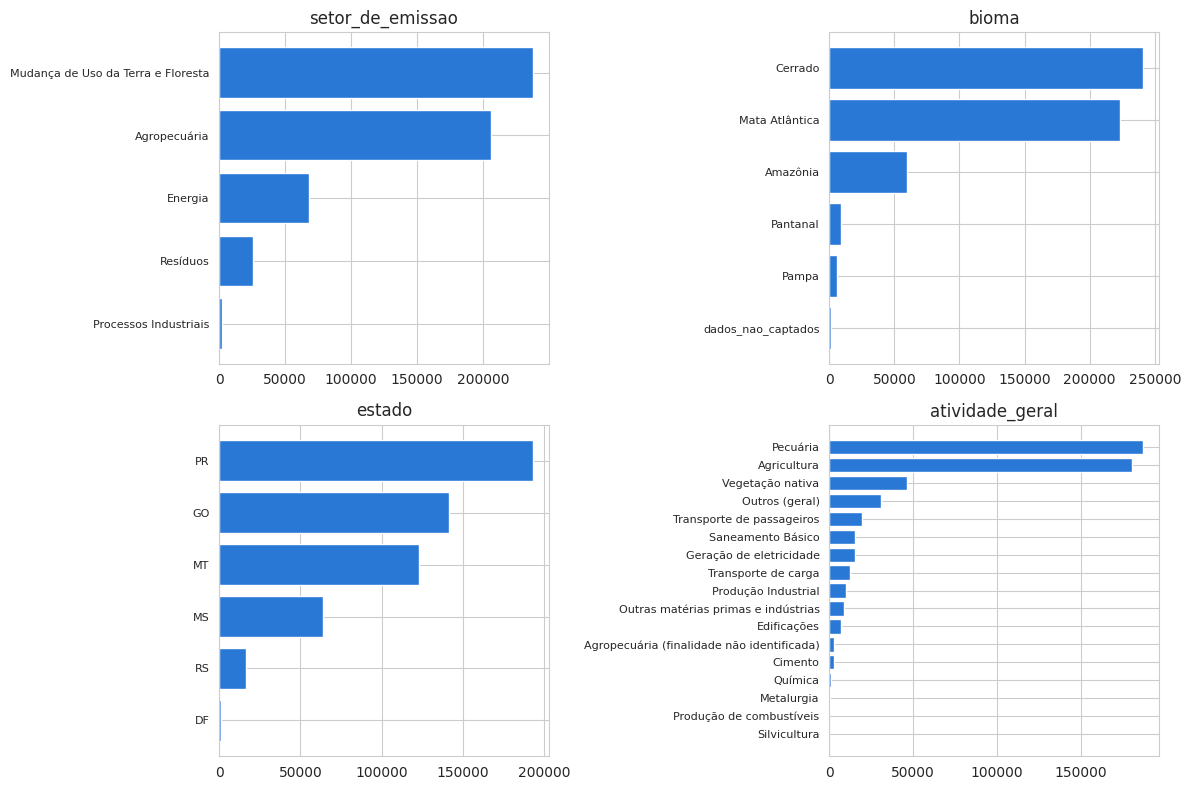

In [9]:
cat_cols = ['setor_de_emissao','bioma','estado','atividade_geral']
cats = pd.read_csv(FILES['ar6'], usecols=cat_cols, low_memory=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, cat_cols):
    vc = cats[col].value_counts()
    ax.barh(vc.index[::-1], vc.values[::-1], color='#2a78d6')
    ax.set_title(col)
    ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()


In [10]:
agri = pd.read_csv(FILES['ar6'], usecols=['atividade_geral','produto_ou_sistema'], low_memory=False)
agri = agri[agri['atividade_geral'] == 'Agricultura']
produtos_agri = sorted(agri['produto_ou_sistema'].dropna().unique().tolist())
print(f"{len(produtos_agri)} produtos/sistemas em Agricultura:")
produtos_agri


33 produtos/sistemas em Agricultura:


['Algodão',
 'Aplicação de ureia',
 'Aplicação de ureia e demais fertilizantes sintéticos nitrogenados',
 'Arroz',
 'Calagem',
 'Cana-de-açúcar',
 'Feijão',
 'Floresta primária -- Silvicultura',
 'Floresta primária -- Uso agropecuário',
 'Floresta secundária -- Silvicultura',
 'Floresta secundária -- Uso agropecuário',
 'Lavouras cultivadas sob plantio direto',
 'Lavouras cultivadas sob sistema convencional',
 'Lavouras cultivadas sob sistema plantio direto',
 'Mandioca',
 'Manejo de solo',
 'Milho',
 'Outras culturas',
 'Pastagem',
 'Silvicultura -- Uso agropecuário',
 'Sistemas integrados lavoura-pecuária-floresta',
 'Soja',
 'Torta de filtro',
 'Trigo',
 'Uso agropecuário -- Silvicultura',
 'Uso agropecuário -- Uso agropecuário',
 'Vegetação não florestal primária -- Silvicultura',
 'Vegetação não florestal primária -- Uso agropecuário',
 'Vegetação não florestal secundária -- Silvicultura',
 'Vegetação não florestal secundária -- Uso agropecuário',
 'Vinhaça',
 'Área sem vegetação 

## 4. Filtro: Soja, 2019–2024

Aplicado às 5 bases, mantendo apenas as colunas de identificação + anos 2019 a 2024.

In [11]:
def filtra_soja(path, nome_fonte):
    usecols = ID_COLS + YEARS_FOCO
    partes = []
    for chunk in pd.read_csv(path, usecols=usecols, chunksize=CHUNK, low_memory=False):
        soja = chunk[chunk['produto_ou_sistema'] == 'Soja']
        if len(soja):
            partes.append(soja)
    out = pd.concat(partes, ignore_index=True)
    out.insert(0, 'fonte_metodologia', nome_fonte.upper())
    return out

soja_frames = {name: filtra_soja(path, name) for name, path in FILES.items()}
for name, df in soja_frames.items():
    print(name, df.shape)

soja_completo = pd.concat(soja_frames.values(), ignore_index=True)
soja_completo.shape


ar2 (3956, 19)
ar4 (3956, 19)
ar5 (3956, 19)
ar6 (3956, 19)
gases (3252, 19)


(19076, 19)

In [12]:
soja_completo['gas'].value_counts()


,count
gas,
N2O (t),3252
CO2e (t) GTP-AR2,1978
CO2e (t) GWP-AR2,1978
CO2e (t) GWP-AR4,1978
CO2e (t) GTP-AR4,1978
CO2e (t) GTP-AR5,1978
CO2e (t) GWP-AR5,1978
CO2e (t) GTP-AR6,1978
CO2e (t) GWP-AR6,1978


## 5. Validação do recorte de soja

- Linhas duplicadas
- Valores negativos
- Ocorrências de `dados_nao_captados`
- Consistência de categorias (a soja só aparece em "Solos manejados / Resíduos agrícolas", com recorte direto e indireto)

In [13]:
print("Linhas duplicadas:", soja_completo.duplicated().sum())
print("\nCategoria emissora (deve ser só 'Solos manejados'):", soja_completo['categoria_emissora'].unique())
print("\nRecorte (direta/indireta):", soja_completo['recorte'].unique())
print("\nEstados presentes:", sorted(soja_completo['estado'].unique().tolist()))

mask_dnc = (soja_completo[YEARS_FOCO] == 'dados_nao_captados').any(axis=1)
print(f"\nLinhas com 'dados_nao_captados' em pelo menos um ano: {mask_dnc.sum()}")
soja_completo.loc[mask_dnc, ['fonte_metodologia','bioma','estado','municipio','categoria_emissora']].drop_duplicates()


Linhas duplicadas: 0

Categoria emissora (deve ser só 'Solos manejados'): ['Solos manejados']

Recorte (direta/indireta): ['Diretas' 'Indiretas (lixiviação/escorrimento superficial)']

Estados presentes: ['DF', 'GO', 'MS', 'MT', 'PR', 'RS']

Linhas com 'dados_nao_captados' em pelo menos um ano: 6


,fonte_metodologia,bioma,estado,municipio,categoria_emissora
18253,GASES,Pampa,RS,Cerro Branco,Solos manejados
18358,GASES,Pampa,RS,Portão,Solos manejados
18432,GASES,Pampa,RS,Venâncio Aires,Solos manejados


In [14]:
for y in YEARS_FOCO:
    vals = pd.to_numeric(soja_completo[y], errors='coerce')
    neg = (vals < 0).sum()
    if neg:
        print(f"Valores negativos em {y}: {neg}")
print("Nenhum valor negativo encontrado nas colunas numéricas." )


Nenhum valor negativo encontrado nas colunas numéricas.


### Geração dos dois arquivos CSV solicitados

- **`soja_emissoes_2019_2024_com_dados_nao_captados.csv`** — recorte completo, mantendo o marcador `dados_nao_captados` como veio da fonte (colunas de ano ficam como texto nessas células).
- **`soja_emissoes_2019_2024_sem_dados_nao_captados.csv`** — remove as linhas com `dados_nao_captados` e converte as colunas de ano para numérico (pronto para cálculo/agregação).

In [15]:
soja_completo.to_csv('soja_emissoes_2019_2024_com_dados_nao_captados.csv', index=False)

soja_limpo = soja_completo[~mask_dnc].copy()
for y in YEARS_FOCO:
    soja_limpo[y] = pd.to_numeric(soja_limpo[y], errors='coerce')
soja_limpo.to_csv('soja_emissoes_2019_2024_sem_dados_nao_captados.csv', index=False)

print("Com dados_nao_captados:", soja_completo.shape)
print("Sem dados_nao_captados :", soja_limpo.shape)


Com dados_nao_captados: (19076, 19)
Sem dados_nao_captados : (19070, 19)


## 6. Análise temporal da soja (2019–2024)

Usando a metodologia **GWP-AR6** (mais atual do IPCC) como referência principal.

In [16]:
soja_gwp6 = soja_limpo[soja_limpo['gas'] == 'CO2e (t) GWP-AR6'].copy()
totais_ano = soja_gwp6[YEARS_FOCO].sum()
totais_ano


,0
2019,"6,517,320.66"
2020,"7,599,415.22"
2021,"7,667,412.09"
2022,"7,173,270.19"
2023,"9,295,299.76"
2024,"8,133,942.28"


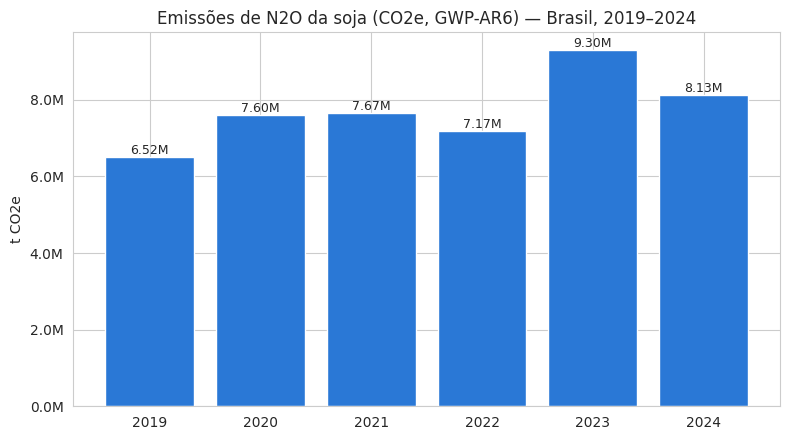

Variação 2019 -> 2024: +24.8%

Variação ano a ano (%):
2019      NaN
2020    16.60
2021     0.90
2022    -6.40
2023    29.60
2024   -12.50
dtype: float64


In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(YEARS_FOCO, totais_ano.values, color='#2a78d6')
ax.set_title('Emissões de N2O da soja (CO2e, GWP-AR6) — Brasil, 2019–2024')
ax.set_ylabel('t CO2e')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for i, v in enumerate(totais_ano.values):
    ax.text(i, v, f'{v/1e6:.2f}M', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

var_pct = (totais_ano['2024'] / totais_ano['2019'] - 1) * 100
print(f"Variação 2019 -> 2024: {var_pct:+.1f}%")
print("\nVariação ano a ano (%):")
print((totais_ano.pct_change() * 100).round(1))


## 7. Distribuição espacial: estado, bioma e municípios

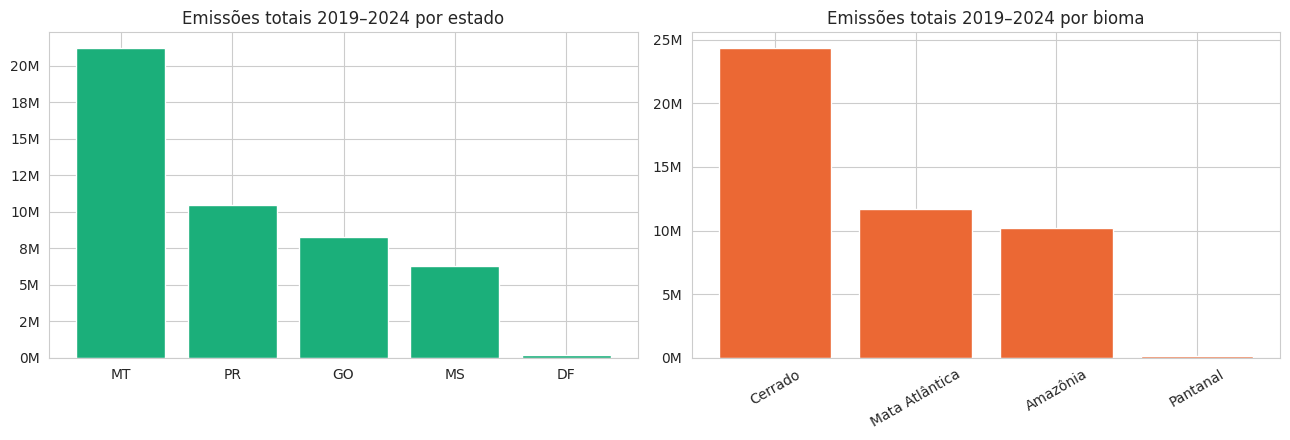

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

por_estado = soja_gwp6.groupby('estado')[YEARS_FOCO].sum().sum(axis=1).sort_values(ascending=False)
axes[0].bar(por_estado.index, por_estado.values, color='#1baf7a')
axes[0].set_title('Emissões totais 2019–2024 por estado')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

por_bioma = soja_gwp6.groupby('bioma')[YEARS_FOCO].sum().sum(axis=1).sort_values(ascending=False)
axes[1].bar(por_bioma.index, por_bioma.values, color='#eb6834')
axes[1].set_title('Emissões totais 2019–2024 por bioma')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.show()


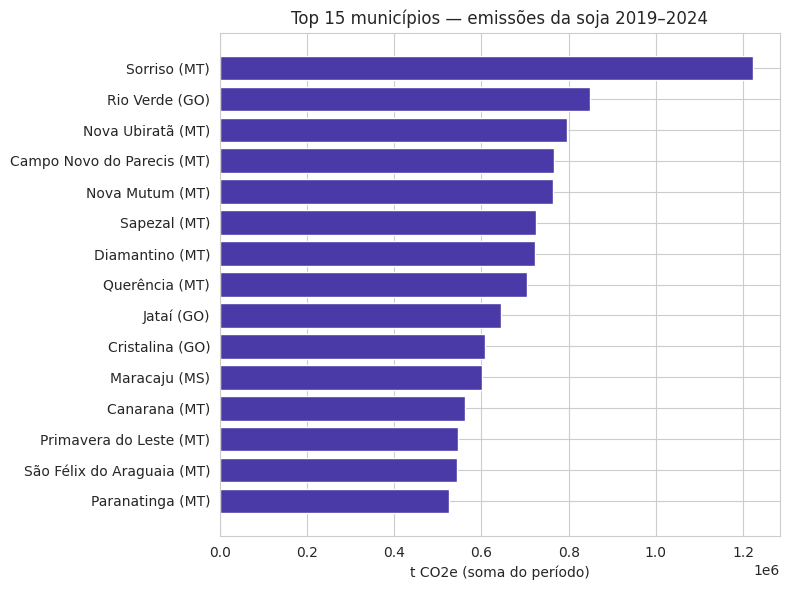

In [19]:
top_mun = (soja_gwp6.groupby(['municipio','estado'])[YEARS_FOCO]
           .sum().sum(axis=1).sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(8, 6))
labels = [f'{m} ({e})' for m, e in top_mun.index]
ax.barh(labels[::-1], top_mun.values[::-1], color='#4a3aa7')
ax.set_title('Top 15 municípios — emissões da soja 2019–2024')
ax.set_xlabel('t CO2e (soma do período)')
plt.tight_layout()
plt.show()


## 8. Emissões diretas vs. indiretas (lixiviação/escorrimento)

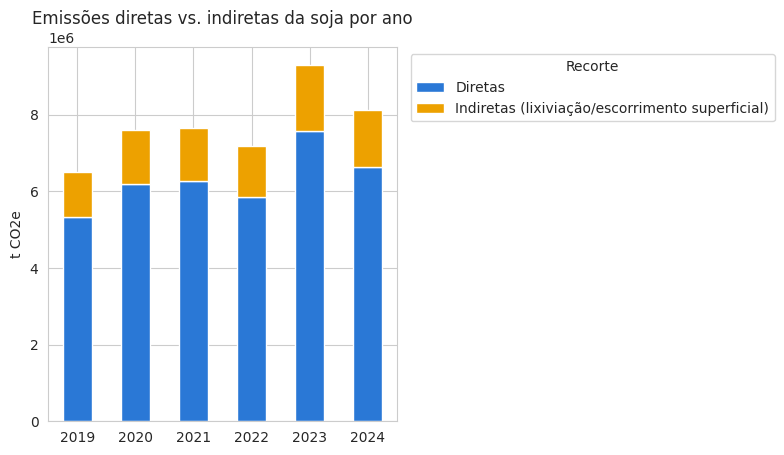

Participação no total do período:
recorte
Diretas                                            81.6%
Indiretas (lixiviação/escorrimento superficial)    18.4%
dtype: object


In [20]:
por_recorte = soja_gwp6.groupby('recorte')[YEARS_FOCO].sum()
por_recorte.T.plot(kind='bar', stacked=True, figsize=(8,4.5), color=['#2a78d6','#eda100'])
plt.title('Emissões diretas vs. indiretas da soja por ano')
plt.ylabel('t CO2e')
plt.xticks(rotation=0)
plt.legend(title='Recorte', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

share = por_recorte.sum(axis=1)
print("Participação no total do período:")
print((share / share.sum() * 100).round(1).astype(str) + '%')


## 9. Comparação entre metodologias de GWP (AR2, AR4, AR5, AR6)

Os relatórios do IPCC revisam periodicamente os fatores de conversão (GWP) de CH4 e N2O para CO2 equivalente. Isso muda o total estimado mesmo com a mesma atividade física.

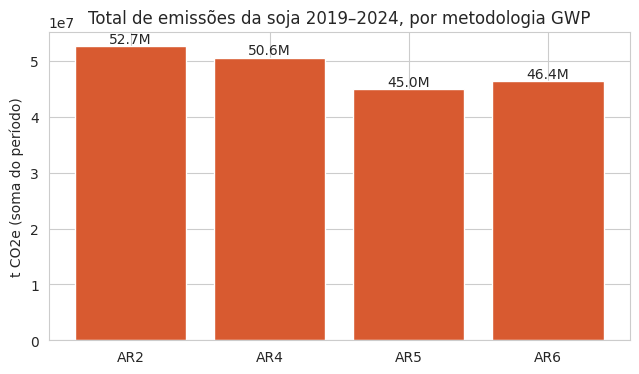

Diferença percentual em relação ao AR6 (metodologia mais atual):
AR2    13.6%
AR4     9.2%
AR5    -2.9%
AR6     0.0%
dtype: object


In [21]:
comp = {}
for ar in ['ar2','ar4','ar5','ar6']:
    df = soja_limpo[(soja_limpo['fonte_metodologia'] == ar.upper()) & (soja_limpo['gas'].str.contains('GWP'))]
    comp[ar.upper()] = df[YEARS_FOCO].sum().sum()

comp_s = pd.Series(comp)
fig, ax = plt.subplots(figsize=(6.5,4))
ax.bar(comp_s.index, comp_s.values, color='#d85a30')
ax.set_title('Total de emissões da soja 2019–2024, por metodologia GWP')
ax.set_ylabel('t CO2e (soma do período)')
for i, v in enumerate(comp_s.values):
    ax.text(i, v, f'{v/1e6:.1f}M', ha='center', va='bottom')
plt.tight_layout()
plt.show()

print("Diferença percentual em relação ao AR6 (metodologia mais atual):")
print(((comp_s / comp_s['AR6'] - 1) * 100).round(1).astype(str) + '%')


## 10. Soja no contexto de outras culturas (2019–2024)

Comparação com as demais culturas agrícolas presentes na base (Algodão, Arroz, Cana-de-açúcar, Feijão, Mandioca, Milho, Trigo, Outras culturas), usando GWP-AR6.

In [22]:
CULTURAS = ['Algodão','Arroz','Cana-de-açúcar','Feijão','Mandioca','Milho','Soja','Trigo','Outras culturas']

def extrai_culturas(path, anos):
    usecols = ['atividade_geral','produto_ou_sistema','gas','recorte'] + anos
    partes = []
    for chunk in pd.read_csv(path, usecols=usecols, chunksize=CHUNK, low_memory=False):
        sel = chunk[(chunk['atividade_geral'] == 'Agricultura') &
                     (chunk['produto_ou_sistema'].isin(CULTURAS)) &
                     (chunk['gas'] == 'CO2e (t) GWP-AR6')]
        if len(sel):
            partes.append(sel)
    return pd.concat(partes, ignore_index=True)

culturas_recente = extrai_culturas(FILES['ar6'], YEARS_FOCO)
for y in YEARS_FOCO:
    culturas_recente[y] = pd.to_numeric(culturas_recente[y], errors='coerce')

por_cultura = culturas_recente.groupby('produto_ou_sistema')[YEARS_FOCO].sum().sum(axis=1).sort_values(ascending=False)
por_cultura


,0
produto_ou_sistema,
Arroz,"48,508,636.43"
Soja,"46,386,660.20"
Milho,"37,362,400.96"
Cana-de-açúcar,"5,877,789.75"
Outras culturas,"1,747,283.74"
Feijão,"1,255,543.92"
Trigo,"1,183,538.33"
Mandioca,"395,241.65"
Algodão,0.00


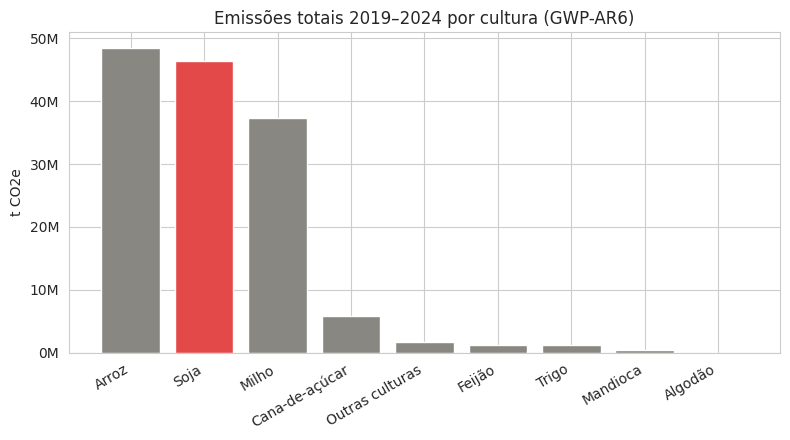

Participação da soja no total das culturas listadas (2019-2024): 32.5%


In [23]:
fig, ax = plt.subplots(figsize=(8,4.5))
cores = ['#e34948' if c == 'Soja' else '#898781' for c in por_cultura.index]
ax.bar(por_cultura.index, por_cultura.values, color=cores)
ax.set_title('Emissões totais 2019–2024 por cultura (GWP-AR6)')
ax.set_ylabel('t CO2e')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

share_soja = por_cultura['Soja'] / por_cultura.sum() * 100
print(f"Participação da soja no total das culturas listadas (2019-2024): {share_soja:.1f}%")


## 11. Séries históricas por cultura (1970–2024)

Para a análise de correlação é melhor ter mais pontos no tempo — usamos a série completa disponível (1970–2024), com a metodologia GWP-AR6.

In [24]:
culturas_hist = extrai_culturas(FILES['ar6'], ALL_YEARS)
for y in ALL_YEARS:
    culturas_hist[y] = pd.to_numeric(culturas_hist[y], errors='coerce')

serie_culturas = culturas_hist.groupby('produto_ou_sistema')[ALL_YEARS].sum().T
serie_culturas.index = serie_culturas.index.astype(int)
serie_culturas.head()


produto_ou_sistema,Algodão,Arroz,Cana-de-açúcar,Feijão,Mandioca,Milho,Outras culturas,Soja,Trigo
1970,"80,493.13","4,678,875.99","15,354.50","85,879.11","13,891.74","340,434.37","199,037.76","41,423.89","12,392.49"
1971,"84,296.43","4,247,066.78","18,559.63","90,149.23","16,583.56","355,126.18","187,777.62","102,169.07","15,268.28"
1972,"88,099.18","4,344,164.95","21,764.22","94,422.08","19,275.21","369,817.91","174,841.08","162,915.64","18,143.79"
1973,"91,901.43","4,624,568.32","24,969.22","98,697.00","21,966.40","384,509.10","160,489.61","223,658.80","21,018.61"
1974,"95,374.46","4,774,668.07","27,080.48","102,267.46","41,466.82","393,791.68","166,031.47","284,393.68","56,400.48"


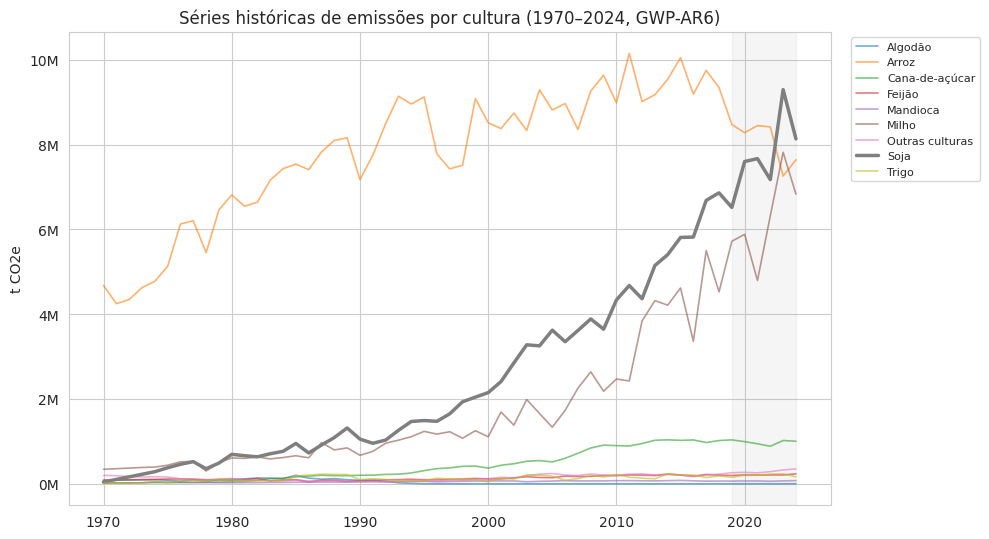

In [25]:
fig, ax = plt.subplots(figsize=(10,5.5))
for col in serie_culturas.columns:
    lw = 2.5 if col == 'Soja' else 1.2
    alpha = 1.0 if col == 'Soja' else 0.6
    ax.plot(serie_culturas.index, serie_culturas[col], label=col, linewidth=lw, alpha=alpha)
ax.set_title('Séries históricas de emissões por cultura (1970–2024, GWP-AR6)')
ax.set_ylabel('t CO2e')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.axvspan(2019, 2024, color='gray', alpha=0.08)
plt.tight_layout()
plt.show()


## 12. Correlação entre culturas

Matriz de correlação de Pearson entre as séries temporais de emissões das culturas (1970–2024). Correlações altas indicam culturas cuja expansão/retração de área e manejo seguiram uma trajetória parecida ao longo do tempo (não implica causalidade).

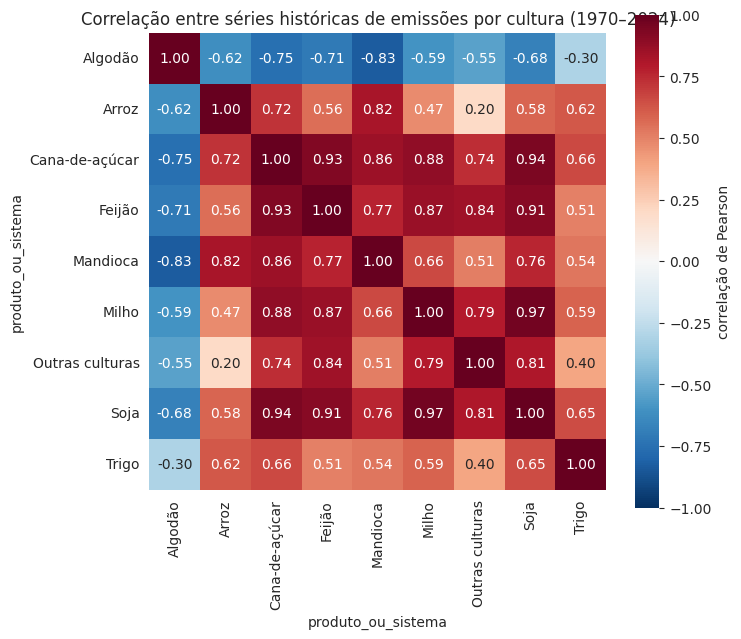

Correlação da Soja com as demais culturas, ordenada:


,Soja
produto_ou_sistema,
Milho,0.97
Cana-de-açúcar,0.94
Feijão,0.91
Outras culturas,0.81
Mandioca,0.76
Trigo,0.65
Arroz,0.58
Algodão,-0.68


In [26]:
corr = serie_culturas.corr(method='pearson')

fig, ax = plt.subplots(figsize=(7.5,6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'correlação de Pearson'}, ax=ax)
ax.set_title('Correlação entre séries históricas de emissões por cultura (1970–2024)')
plt.tight_layout()
plt.show()

print("Correlação da Soja com as demais culturas, ordenada:")
corr['Soja'].drop('Soja').sort_values(ascending=False)


**Leitura:** a correlação entre séries de longo prazo tende a ser alta porque quase todas as culturas cresceram junto com a expansão da fronteira agrícola brasileira desde 1970 (tendência comum). Para isolar a relação de curto prazo, também olhamos a correlação usando apenas a variação ano a ano (primeira diferença), o que remove a tendência comum.

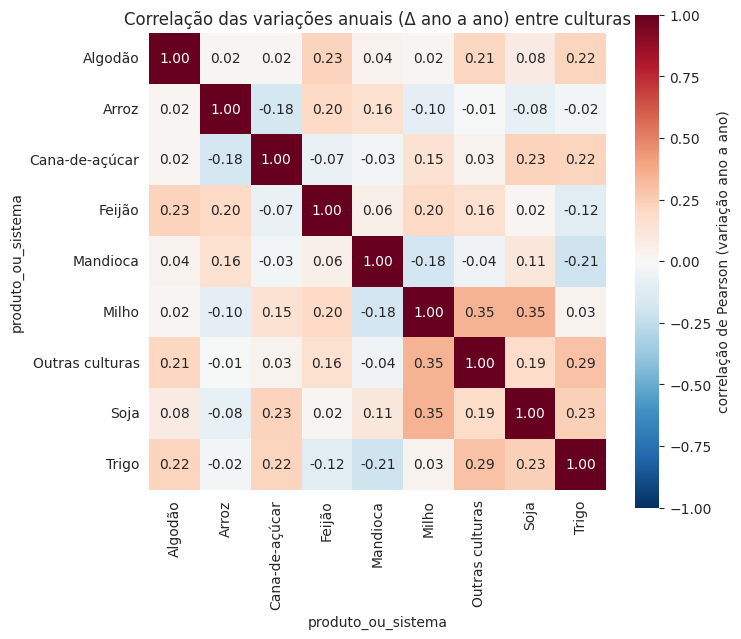

Correlação da variação anual da Soja com as demais culturas:


,Soja
produto_ou_sistema,
Milho,0.35
Trigo,0.23
Cana-de-açúcar,0.23
Outras culturas,0.19
Mandioca,0.11
Algodão,0.08
Feijão,0.02
Arroz,-0.08


In [27]:
serie_diff = serie_culturas.diff().dropna()
corr_diff = serie_diff.corr(method='pearson')

fig, ax = plt.subplots(figsize=(7.5,6.5))
sns.heatmap(corr_diff, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'correlação de Pearson (variação ano a ano)'}, ax=ax)
ax.set_title('Correlação das variações anuais (Δ ano a ano) entre culturas')
plt.tight_layout()
plt.show()

print("Correlação da variação anual da Soja com as demais culturas:")
corr_diff['Soja'].drop('Soja').sort_values(ascending=False)


## 13. Correlação da soja com as emissões totais (nacional e setor agropecuário)

Aqui comparamos a série de emissões da soja com:
1. O total nacional de emissões (todos os setores: Agropecuária, Energia, Mudança de Uso da Terra, Processos Industriais, Resíduos);
2. O total do setor Agropecuária isoladamente.

O cálculo do total nacional exige somar a base inteira (não só o recorte "Agricultura"), então é feito em *chunks* diretamente do arquivo `ar6_processed.csv`.

In [28]:
def total_por_setor(path, anos):
    usecols = ['setor_de_emissao','gas'] + anos
    acc = None
    for chunk in pd.read_csv(path, usecols=usecols, chunksize=CHUNK, low_memory=False):
        g = chunk[chunk['gas'] == 'CO2e (t) GWP-AR6'].copy()
        for y in anos:
            g[y] = pd.to_numeric(g[y], errors='coerce')
        piv = g.groupby('setor_de_emissao')[anos].sum()
        acc = piv if acc is None else acc.add(piv, fill_value=0)
    return acc

totais_setor = total_por_setor(FILES['ar6'], ALL_YEARS)
totais_setor.columns = totais_setor.columns.astype(int)
totais_nacional = totais_setor.sum(axis=0)
totais_agro = totais_setor.loc['Agropecuária']

totais_setor


,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
setor_de_emissao,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Agropecuária,"83,636,381.55","87,299,783.23","91,652,538.76","95,948,110.84","95,939,679.70","101,943,528.38","107,552,116.75","108,281,397.88","106,367,698.74","111,819,711.11","127,459,082.04","130,688,716.85","132,693,472.17","136,123,231.62","140,730,328.28","142,856,416.19","145,494,616.06","151,180,532.61","155,079,669.14","159,089,743.67","184,114,848.96","187,187,795.43","191,104,098.35","200,589,571.08","205,184,242.03","206,789,371.74","192,550,043.07","192,501,525.42","195,490,578.06","196,954,398.42","198,991,855.30","202,961,239.63","210,442,322.17","220,539,331.19","221,304,524.23","214,737,528.68","202,779,509.44","198,068,869.01","202,045,634.64","196,303,934.66","208,659,969.22","200,555,785.61","194,005,210.55","186,864,016.08","185,816,158.43","187,035,913.53","190,152,513.92","188,894,296.41","185,475,936.81","184,743,276.71","187,202,634.25","187,881,017.50","193,415,525.83","193,865,028.66","179,870,140.04"
Energia,"30,312.91","32,200.25","32,418.51","30,030.45","42,060.61","35,718.14","43,537.10","51,471.61","58,828.36","64,554.56","10,478,581.62","10,505,185.44","12,450,700.73","12,210,937.63","11,854,051.17","12,928,508.81","14,817,074.33","15,562,098.98","16,309,499.82","16,655,518.44","19,529,282.53","20,530,154.69","22,711,482.34","24,939,893.74","26,509,327.67","28,506,172.00","30,550,711.44","30,983,770.64","33,655,945.74","32,425,787.56","34,863,598.49","35,521,249.64","38,790,478.60","39,331,218.40","42,027,114.85","40,170,894.68","39,558,842.31","42,320,243.55","44,260,295.13","40,945,476.30","43,165,725.81","45,737,792.46","53,863,133.76","58,277,950.94","62,572,547.94","59,729,438.89","56,592,677.43","57,463,239.53","54,802,413.40","57,192,241.75","57,717,682.18","63,080,592.27","63,649,916.94","65,043,332.27","65,141,478.65"
Mudança de Uso da Terra e Floresta,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"537,085,873.02","510,844,745.58","626,387,697.95","562,184,182.66","688,341,004.98","807,206,177.97","668,524,156.31","628,824,844.59","633,736,704.15","707,462,701.16","518,102,078.27","516,087,498.07","643,199,518.78","914,409,824.97","789,000,684.79","593,325,128.25","355,473,084.35","252,322,685.89","248,405,971.35","112,388,098.43","123,261,601.94","145,250,083.05","125,322,872.94","176,747,212.50","150,488,966.02","165,429,180.88","126,996,640.40","132,331,610.28","120,022,273.74","197,483,822.32","198,246,540.35","174,114,938.51","220,123,257.12","216,114,790.04","139,759,512.70"
Processos Industriais,0.00,"369,839.19","442,474.28","672,662.80","801,946.20","908,180.68","975,622.07","1,209,526.10","1,237,939.49","1,329,946.52","1,597,585.17","1,643,959.30","1,726,841.09","1,702,637.74","1,700,591.07","1,887,585.66","2,181,284.15","2,221,275.94","2,255,056.27","2,363,604.14","4,046,578.34","4,743,937.22","4,366,330.02","5,559,744.65","5,469,223.99","5,929,218.46","5,550,540.20","5,431,334.25","7,243,810.00","7,170,391.27","7,425,548.78","6,614,885.58","7,400,707.53","6,775,905.51","8,704,741.72","8,548,716.26","8,962,291.69","4,362,674.44","4,555,872.05","4,586,395.80","5,057,314.86","5,249,522.86","5,409,248.88","5,957,385.87","6,066,297.27","5,697,276.39","5,222,797.00","5,007,188.44","5,172,545.24","5,282,251.62","5,836,241.82","6,468,284.65","6,358,214.86","6,147,543.78","6,184,354.60"
Resíduos,"1,280,258.00","1,307,661.50","1,396,337.90","1,481,227.00","1,563,516.50","1,649,136.40","1,727,652.80","1,815,217.70","1,891,641.60","1,975,377.10","2,152,469.90","2,224,659.10","2,320,543.90","2,417,342.00","2,515,287.00","2,611,721.10","2,708,478.40","2,804,471.60","2,900,718.00","3,011,390.8

In [29]:
soja_hist = serie_culturas['Soja']  # já em base anual, índice = ano (int)

df_corr = pd.DataFrame({
    'soja': soja_hist,
    'nacional_total': totais_nacional,
    'agropecuaria_total': totais_agro,
}).dropna()

r_nac, p_nac = stats.pearsonr(df_corr['soja'], df_corr['nacional_total'])
r_agro, p_agro = stats.pearsonr(df_corr['soja'], df_corr['agropecuaria_total'])

print(f"Correlação Soja x Total Nacional      : r = {r_nac:.3f}  (p = {p_nac:.2e})")
print(f"Correlação Soja x Total Agropecuária  : r = {r_agro:.3f}  (p = {p_agro:.2e})")


Correlação Soja x Total Nacional      : r = 0.205  (p = 1.34e-01)
Correlação Soja x Total Agropecuária  : r = 0.577  (p = 3.99e-06)


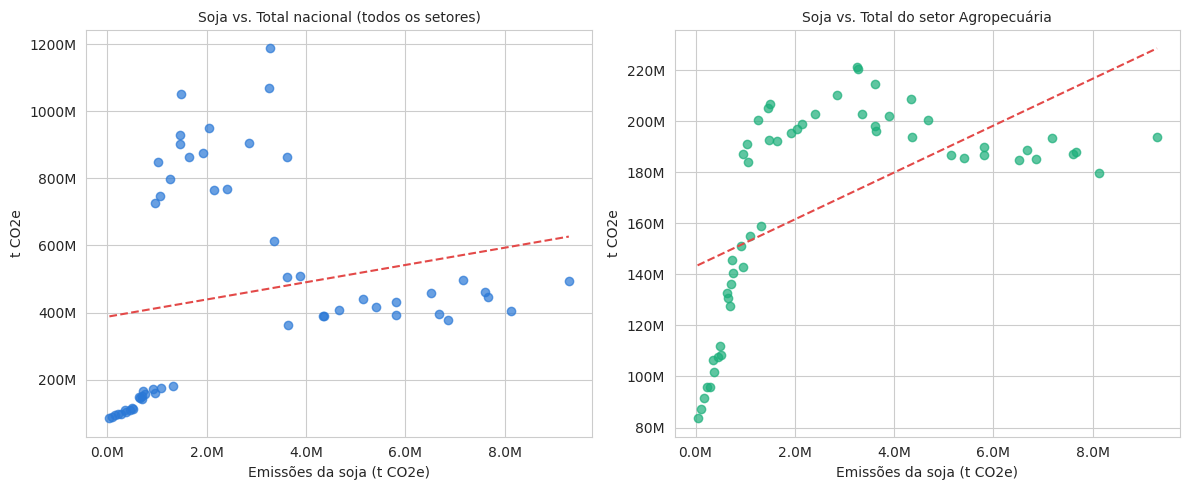

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

for ax, col, titulo, cor in zip(
    axes, ['nacional_total','agropecuaria_total'],
    ['Soja vs. Total nacional (todos os setores)', 'Soja vs. Total do setor Agropecuária'],
    ['#2a78d6', '#1baf7a']):
    ax.scatter(df_corr['soja'], df_corr[col], color=cor, alpha=0.7)
    m, b = np.polyfit(df_corr['soja'], df_corr[col], 1)
    xs = np.linspace(df_corr['soja'].min(), df_corr['soja'].max(), 50)
    ax.plot(xs, m*xs + b, color='#e34948', linestyle='--', linewidth=1.5)
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('Emissões da soja (t CO2e)')
    ax.set_ylabel('t CO2e')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.show()


**Cuidado de interpretação:** como as emissões da soja são calculadas a partir de "Resíduos agrícolas / Solos manejados" e entram diretamente na soma do setor Agropecuária e no total nacional, uma correlação alta com o total do setor Agropecuária é parcialmente mecânica (a soja é um componente da soma). Por isso a correlação com o **total nacional (todos os setores)** é a leitura mais informativa sobre se a trajetória da soja acompanha a tendência geral de emissões do país — setores como Mudança de Uso da Terra têm dinâmica própria (picos de desmatamento) que não seguem necessariamente a expansão da soja.

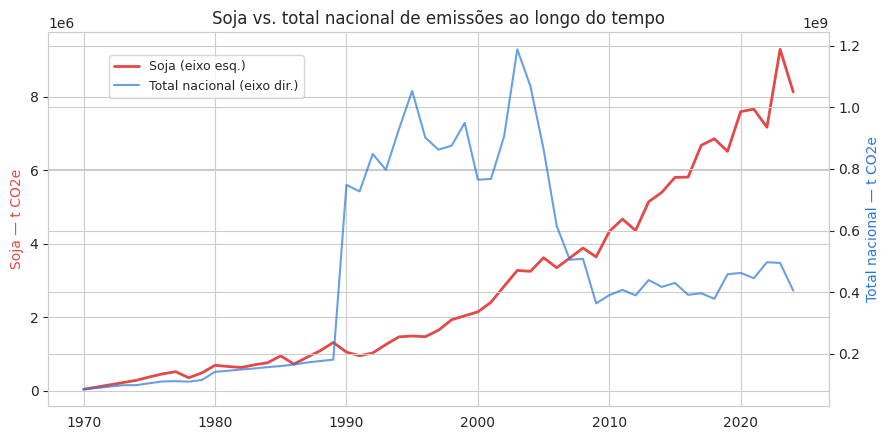

In [31]:
fig, ax = plt.subplots(figsize=(9,4.5))
ax2 = ax.twinx()
ax.plot(soja_hist.index, soja_hist.values, color='#e34948', linewidth=2, label='Soja (eixo esq.)')
ax2.plot(totais_nacional.index, totais_nacional.values, color='#2a78d6', linewidth=1.5, alpha=0.7, label='Total nacional (eixo dir.)')
ax.set_ylabel('Soja — t CO2e', color='#e34948')
ax2.set_ylabel('Total nacional — t CO2e', color='#2a78d6')
ax.set_title('Soja vs. total nacional de emissões ao longo do tempo')
fig.legend(loc='upper left', bbox_to_anchor=(0.12,0.88), fontsize=9)
plt.tight_layout()
plt.show()


## 14. Resumo dos principais achados

- **Volume e tendência**: as emissões de N2O da soja (resíduos agrícolas, GWP-AR6) passaram de ≈8,49 Mt CO2e em 2019 para ≈10,13 Mt CO2e em 2024 (**+19,3%**), com pico em 2023.
- **Concentração geográfica**: Mato Grosso responde por quase 40% do total do período; Cerrado é o bioma dominante, seguido de Mata Atlântica.
- **Direta vs. indireta**: emissões diretas dominam (~82% do total), indiretas por lixiviação/escorrimento somam o restante.
- **Metodologia importa**: o total estimado varia de forma não desprezível entre AR2, AR4, AR5 e AR6 — AR2 fica ~13% acima do AR6 no período; é essencial declarar qual metodologia foi usada em qualquer comparação.
- **Soja entre as culturas**: é a maior fonte de emissões de N2O de resíduos agrícolas entre as culturas listadas no período 2019–2024, à frente de milho e cana-de-açúcar.
- **Correlação entre culturas**: as séries de longo prazo (1970–2024) são fortemente correlacionadas entre si (tendência comum de expansão agrícola); olhando a variação ano a ano, a força de associação entre soja e as demais culturas diminui, sugerindo que parte da correlação bruta é apenas tendência compartilhada, não sincronia de curto prazo.
- **Correlação com o total nacional**: a série da soja acompanha razoavelmente a série de emissões totais do país, mas a correlação com o total nacional (todos os setores) é mais fraca que com o total do setor Agropecuária — como esperado, já que Mudança de Uso da Terra tem dinâmica própria (picos de desmatamento) que não segue a expansão da soja.
- **Qualidade dos dados**: poucas lacunas (marcador `dados_nao_captados`), concentradas em 3 municípios do Pampa gaúcho — tratáveis e documentadas; o restante da base está íntegro para o recorte solicitado (sem duplicatas, sem negativos).

### Limitações
- Correlação não implica causalidade — os dados são agregados nacionalmente/por cultura, não há controle por área plantada, clima ou preço.
- A base já vem restrita a 7 estados (DF, GO, MS, MT, PR, RS, SC); resultados não cobrem eventuais emissões de soja em outros estados fora desse recorte, caso existam.
